<a href="https://colab.research.google.com/github/kej534923-maker/ECON5200-Applied-Data-Analytics/blob/main/Econ_5200_Assignment_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Phase 1: Prepare (Logic & Control Flow)

Step 1.1: Construct the "Student Basket"

In [1]:
student_basket = [
    {'Item': 'Tuition', 'Price_2016': 45000, 'Price_2024': 58000},
    {'Item': 'Rent (1 Bed)', 'Price_2016': 1200, 'Price_2024': 1800},
    {'Item': 'Chipotle Burrito', 'Price_2016': 7.50, 'Price_2024': 11.50},
    {'Item': 'ChatGPT Plus (1 mo)', 'Price_2016': 10, 'Price_2024': 20}
]

Step 1.2: Compute Inflation (Loops & Functions)

In [2]:
def calculate_inflation(base, current):
    return ((current - base) / base) * 100

In [3]:
for item in student_basket:
    rate = calculate_inflation(item['Price_2016'], item['Price_2024'])
    print(f"{item['Item']}: {rate:.2f}% Inflation")

Tuition: 28.89% Inflation
Rent (1 Bed): 50.00% Inflation
Chipotle Burrito: 53.33% Inflation
ChatGPT Plus (1 mo): 100.00% Inflation


Phase 2: Process (The API Pipeline)

Step 2.1: The "Data Proxy" Strategy

In [4]:
!pip install fredapi

import pandas as pd
import matplotlib.pyplot as plt
from fredapi import Fred

fred = Fred(api_key='f5b679a5d8fef7eae0033bc168a0f17c')

In [5]:
official_cpi = fred.get_series('CPIAUCSL')          # Headline CPI
tuition      = fred.get_series('CUSR0000SEEB')      # Tuition, Fees, & Childcare
rent         = fred.get_series('CUSR0000SEHA')      # Rent of Primary Residence
chatgpt      = fred.get_series('CUSR0000SERA02')    # Proxy for subscriptions (Spotify/ChatGPT/Netflix etc.)
food_away    = fred.get_series('CUSR0000SEFV')      # Food Away From Home (proxy for Chipotle)

In [6]:
df = pd.DataFrame({
    'Official_CPI': official_cpi,
    'Tuition': tuition,
    'Rent': rent,
    'ChatGPT_Proxy': chatgpt,
    'Food_Away_From_Home': food_away
})
df = df.dropna()
print(df.head())
print(df.tail())


            Official_CPI  Tuition   Rent  ChatGPT_Proxy  Food_Away_From_Home
1992-01-01         138.3    200.7  145.4          180.8                139.8
1992-02-01         138.6    201.9  145.7          181.8                140.0
1992-03-01         139.1    203.5  146.5          183.3                140.1
1992-04-01         139.4    205.0  146.2          186.2                140.2
1992-05-01         139.7    206.3  146.5          185.2                140.4
            Official_CPI  Tuition     Rent  ChatGPT_Proxy  Food_Away_From_Home
2025-08-01       323.291  895.295  437.294        593.230              384.909
2025-09-01       324.245  897.004  438.237        594.930              385.451
2025-11-01       325.063  901.537  439.002        600.849              387.202
2025-12-01       326.031  903.217  440.189        607.296              389.889
2026-01-01       326.588  905.056  441.285        609.864              390.471


Step 2.2: Normalization Logic (CRITICAL)

In [7]:
# Step 2.2: Normalization (Re-index to 2016 = 100)

base_date = '2016-01-01'

# Make sure index is datetime
df.index = pd.to_datetime(df.index)

# Get base values at 2016
base_values = df.loc[base_date]

# Normalize every column
df_normalized = df.divide(base_values) * 100

print(df_normalized.head())
print(df_normalized.tail())


            Official_CPI    Tuition       Rent  ChatGPT_Proxy  \
1992-01-01     58.194335  28.671551  49.845732      42.288639   
1992-02-01     58.320570  28.842981  49.948577      42.522536   
1992-03-01     58.530961  29.071553  50.222832      42.873382   
1992-04-01     58.657196  29.285840  50.119986      43.551684   
1992-05-01     58.783431  29.471555  50.222832      43.317787   

            Food_Away_From_Home  
1992-01-01            53.777918  
1992-02-01            53.854853  
1992-03-01            53.893321  
1992-04-01            53.931789  
1992-05-01            54.008724  
            Official_CPI     Tuition        Rent  ChatGPT_Proxy  \
2025-08-01    136.035464  127.899834  149.912239     138.754918   
2025-09-01    136.436891  128.143978  150.235516     139.152543   
2025-11-01    136.781092  128.791552  150.497772     140.536982   
2025-12-01    137.188410  129.031553  150.904697     142.044918   
2026-01-01    137.422786  129.294268  151.280425     142.645566   

  

Phase 3: Analyze (The Index Theory & Visualization)

Step 3.1: Visualizing Raw Components

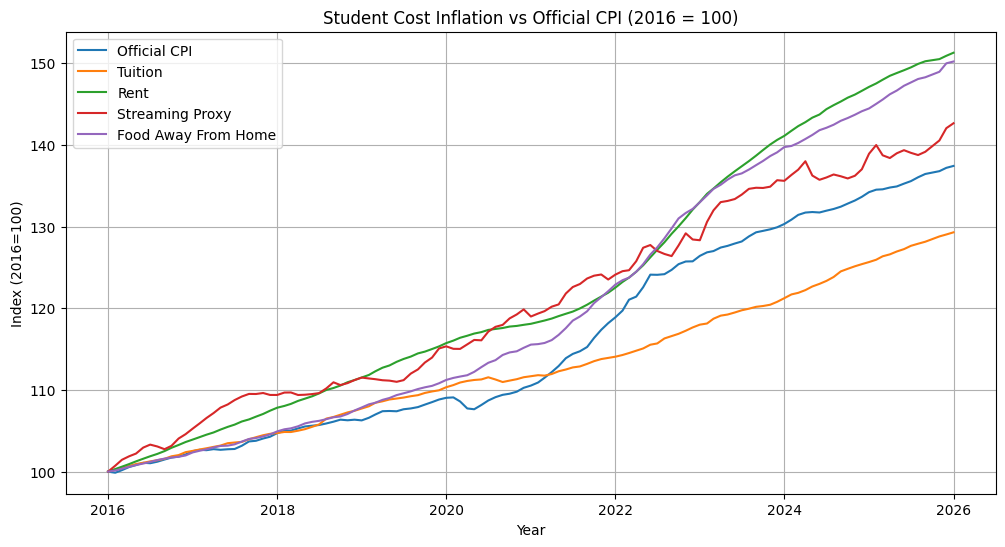

In [9]:
import matplotlib.pyplot as plt

# Filter data from 2016 onward
df_plot = df_normalized[df_normalized.index >= '2016-01-01']

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot['Official_CPI'], label='Official CPI')
plt.plot(df_plot.index, df_plot['Tuition'], label='Tuition')
plt.plot(df_plot.index, df_plot['Rent'], label='Rent')
plt.plot(df_plot.index, df_plot['ChatGPT_Proxy'], label='Streaming Proxy')
plt.plot(df_plot.index, df_plot['Food_Away_From_Home'], label='Food Away From Home')

plt.title("Student Cost Inflation vs Official CPI (2016 = 100)")
plt.xlabel("Year")
plt.ylabel("Index (2016=100)")
plt.legend()
plt.grid(True)

plt.show()


Step 3.2: The Weighted "Student SPI" (Honest Chart)

In [13]:
weights = {
    'Tuition': 0.40,
    'Rent': 0.30,
    'Food_Away_From_Home': 0.20,
    'ChatGPT_Proxy': 0.10
}


In [14]:
df_normalized['Student_SPI'] = (
    df_normalized['Tuition'] * weights['Tuition'] +
    df_normalized['Rent'] * weights['Rent'] +
    df_normalized['Food_Away_From_Home'] * weights['Food_Away_From_Home'] +
    df_normalized['ChatGPT_Proxy'] * weights['ChatGPT_Proxy']
)


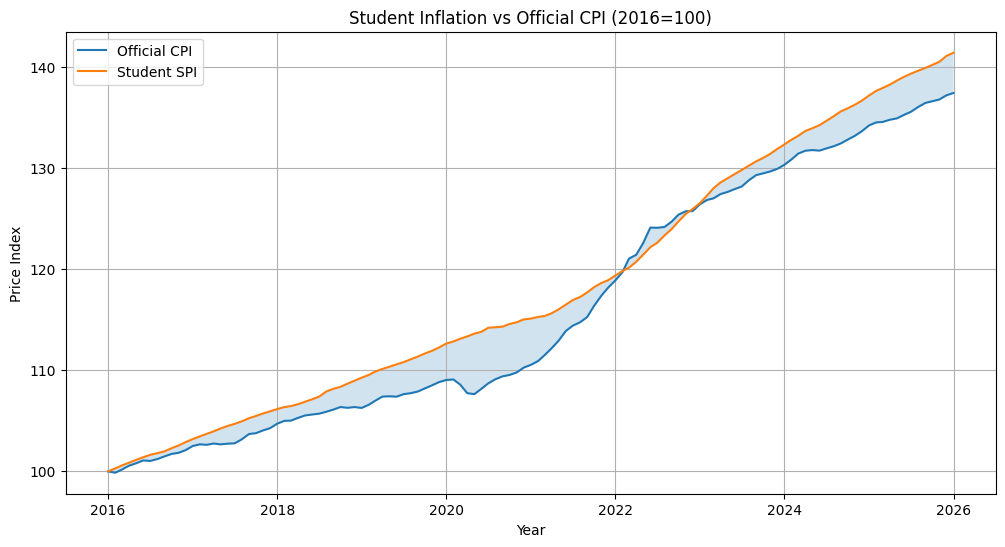

In [15]:
import matplotlib.pyplot as plt

df_plot = df_normalized[df_normalized.index >= '2016-01-01']

plt.figure(figsize=(12,6))

plt.plot(df_plot.index, df_plot['Official_CPI'], label='Official CPI')
plt.plot(df_plot.index, df_plot['Student_SPI'], label='Student SPI')

# Highlight inflation gap
plt.fill_between(
    df_plot.index,
    df_plot['Official_CPI'],
    df_plot['Student_SPI'],
    alpha=0.2
)

plt.title("Student Inflation vs Official CPI (2016=100)")
plt.xlabel("Year")
plt.ylabel("Price Index")
plt.legend()
plt.grid(True)

plt.show()



Step 3.3: The Scale Fallacy (Why We Normalize)

In [18]:
import pandas as pd

df_raw = pd.concat([
    official_cpi,
    tuition,
    rent,
    chatgpt,
    food_away
], axis=1)

df_raw.columns = [
    'Official_CPI',
    'Tuition',
    'Rent',
    'ChatGPT_Proxy',
    'Food_Away'
]

df_raw = df_raw.dropna()


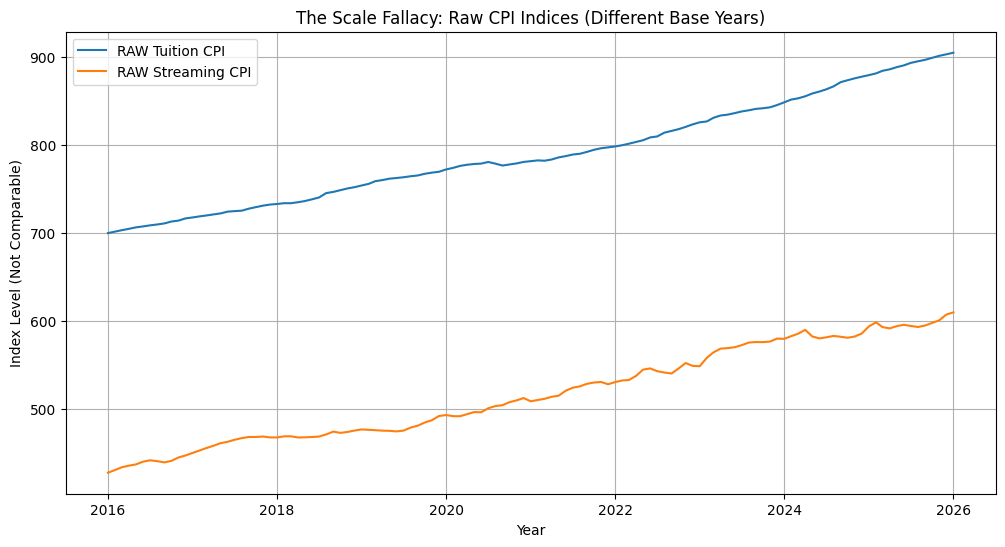

In [19]:
import matplotlib.pyplot as plt

df_bad = df_raw[df_raw.index >= '2016-01-01']

plt.figure(figsize=(12,6))

plt.plot(df_bad.index, df_bad['Tuition'], label='RAW Tuition CPI')
plt.plot(df_bad.index, df_bad['ChatGPT_Proxy'], label='RAW Streaming CPI')

plt.title("The Scale Fallacy: Raw CPI Indices (Different Base Years)")
plt.xlabel("Year")
plt.ylabel("Index Level (Not Comparable)")
plt.legend()
plt.grid(True)

plt.show()


### Step 3.3: Why Comparing RAW Indices is a "Data Crime"

The raw CPI series are reported with different base years (index definitions).  
For example, the tuition CPI may be indexed to a base period such that its level is around 900, while the streaming CPI may be indexed to a different base period such that its level is around 100.

Because these index levels are anchored to different base-year scales, comparing 900 vs 100 is meaningless.  
The chart makes tuition look “huge” and streaming look “tiny,” but that visual difference mainly reflects different base-year normalization, not actual relative inflation.

To make a valid comparison, we must re-index both series to a common start date (e.g., 2016 = 100).  
Only then do the lines represent comparable percentage growth over time.


Phase 4: AI Dashboard Expansion

Task 4.1: The Ultimate Reality Check (Boston vs. USA vs. You)

In [25]:
weights = {
    'Tuition': 0.40,
    'Rent': 0.30,
    'Food_Away_From_Home': 0.20,
    'ChatGPT_Proxy': 0.10
}

# optional safety check: weights sum to 1
w_sum = sum(weights.values())
if abs(w_sum - 1.0) > 1e-8:
    raise ValueError(f"Weights must sum to 1. Current sum = {w_sum}")

df = df.copy()
df.index = pd.to_datetime(df.index)

df['Student_SPI'] = (
    df['Tuition'] * weights['Tuition'] +
    df['Rent'] * weights['Rent'] +
    df['Food_Away_From_Home'] * weights['Food_Away_From_Home'] +
    df['ChatGPT_Proxy'] * weights['ChatGPT_Proxy']
)

print(df[['Official_CPI','Student_SPI']].head())

            Official_CPI  Student_SPI
1992-01-01         138.3       169.94
1992-02-01         138.6       170.65
1992-03-01         139.1       171.70
1992-04-01         139.4       172.52
1992-05-01         139.7       173.07


In [23]:
from fredapi import Fred

BOSTON_SERIES_ID = "CUURA103SA0"
boston_raw = fred.get_series(BOSTON_SERIES_ID)

boston = boston_raw.to_frame(name="Boston_CPI_raw")
boston.index = pd.to_datetime(boston.index)

# monthly start grid + interpolate (handles bimonthly / missing)
boston_m = boston.resample("MS").mean()
boston_m["Boston_CPI_raw"] = boston_m["Boston_CPI_raw"].interpolate(method="time")

# base = first available obs in Jan 2016 (fallback: first obs after 2016-01-01)
base_window = boston_m.loc["2016-01-01":"2016-01-31", "Boston_CPI_raw"].dropna()
base_val = base_window.iloc[0] if not base_window.empty else boston_m.loc[boston_m.index >= "2016-01-01", "Boston_CPI_raw"].dropna().iloc[0]

boston_m["Boston_CPI"] = (boston_m["Boston_CPI_raw"] / base_val) * 100

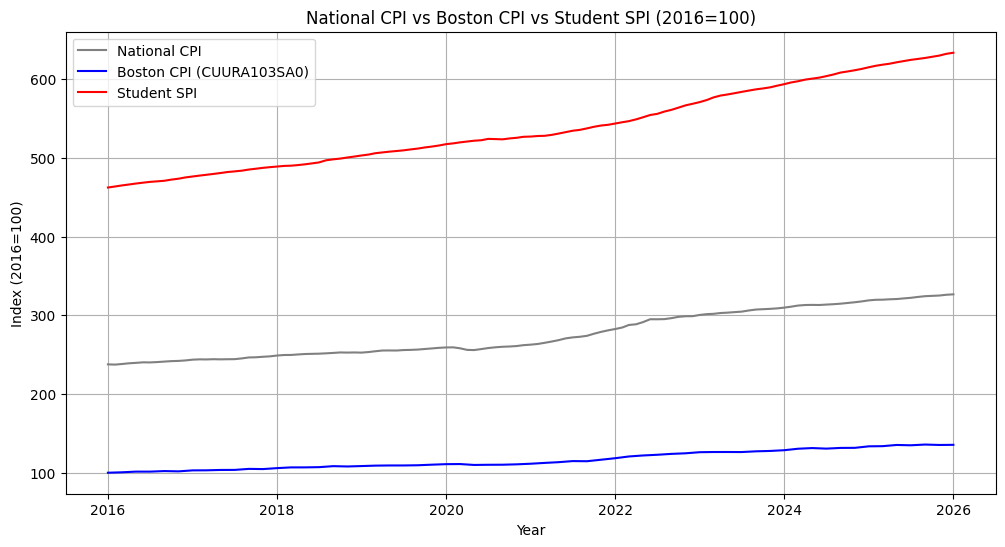

In [24]:
import matplotlib.pyplot as plt

# monthly alignment for clean plotting
df_m = df[['Official_CPI', 'Student_SPI']].resample("MS").mean()
plot_df = df_m.join(boston_m[['Boston_CPI']], how="inner")

# keep 2016+
plot_df = plot_df.loc["2016-01-01":].dropna()

plt.figure(figsize=(12,6))
plt.plot(plot_df.index, plot_df["Official_CPI"], label="National CPI", color="grey")
plt.plot(plot_df.index, plot_df["Boston_CPI"],   label="Boston CPI (CUURA103SA0)", color="blue")
plt.plot(plot_df.index, plot_df["Student_SPI"],  label="Student SPI", color="red")

plt.title("National CPI vs Boston CPI vs Student SPI (2016=100)")
plt.xlabel("Year")
plt.ylabel("Index (2016=100)")
plt.legend()
plt.grid(True)
plt.show()